# M2 — Хроніка блекаутів ⚡

Проєкт **«4331 година»** — клімат квартири та відключення світла, Харків.
Дані реальні: власна система Home Assistant.

Модуль M1 зробив дані чистими. Тут ми ставимо перше справжнє питання до них:
**коли в квартирі не було світла і скільки це тривало.**

Таблиця подій, яку ми тут побудуємо, — вхід для модуля M4 (криві охолодження),
SQL-розділу M8 і дашборда M9.

## Питання

> **Коли і скільки не було світла?**

Підпитання:
1. Як узагалі побачити відключення, якщо в нас немає датчика напруги?
2. Скільки було подій, яка найдовша, скільки годин сумарно?
3. Який uptime квартири за пів року?
4. Чи є закономірність: години доби, дні тижня, місяці?
5. Де наш метод може помилитися?

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import outages

ROOT = pathlib.Path.cwd().parent
IMAGES = ROOT / "images"
RESULTS = ROOT / "results"

pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 80)

hourly, detailed = outages.load_clean(ROOT)
print(f"погодинні: {len(hourly):,} рядків, {hourly.ts.min()} … {hourly.ts.max()}")
print(f"детальні:  {len(detailed):,} рядків, {detailed.ts.min()} … {detailed.ts.max()}")

погодинні: 53,946 рядків, 2026-03-16 08:00:00+00:00 … 2026-09-15 17:00:00+00:00
детальні:  365,047 рядків, 2026-09-05 18:27:33+00:00 … 2026-09-15 18:27:31.884465+00:00


## Дані

Беремо чисті таблиці з M1 — нічого не довантажуємо.

| Таблиця | Що це | Глибина | Роль у M2 |
|---|---|---|---|
| `readings_detailed.csv` | кожна зміна стану, ~14 с | 10 днів | **сигнал A** — короткі відключення |
| `readings_hourly.csv` | година: mean / min / max + прапорець `stuck` | з 16.03.2026 | **сигнал B** — довгі відключення |

Ключова деталь: **усі датчики квартири живляться від розетки, крім датчика квітки**
(`tiny_soil_sensor`, батарейка). А сервер Home Assistant стоїть на ДБЖ.
Саме з цієї асиметрії й народжуються два різні способи побачити блекаут.

## Як ми бачимо відключення

Датчика напруги в квартирі немає. Замість нього — **тиша в даних**.

| Сигнал | Що відбувається | Точність | Глибина |
|---|---|---|---|
| **A. Коротке відключення** | розеткові датчики замовкли, датчик квітки пише далі | секунди | 10 днів |
| **B. Довге відключення** | сервер теж вимкнувся → в даних немає нічого | 1 година | 6 місяців |

**Правило (задане Владом):**

```
дірка < 3 хвилин   →  шум, ігноруємо
дірка ≥ 3 хвилин   →  відключення світла
```

### Той самий крок мовою SQL

Уся детекція — це одна віконна функція: подивитися на попередній запис і
виміряти паузу до наступного.

```sql
WITH d AS (
  SELECT ts,
         LAG(ts) OVER (ORDER BY ts) AS prev_ts
  FROM readings
)
SELECT prev_ts                               AS outage_start,
       ts                                    AS outage_end,
       EXTRACT(EPOCH FROM ts - prev_ts) / 60 AS minutes
FROM d
WHERE ts - prev_ts > INTERVAL '3 minutes';
```

У Python це `outages.find_gaps_detailed()` — той самий `LAG`, тільки `ts.diff()`.

## Сигнал A — короткі відключення (10 днів)

Правило «3 хвилини» саме по собі дає купу хибних спрацювань, тому додаємо два уточнення:

1. **Рахуємо пристрій, а не entity.** Температура, вологість і освітленість
   житлової кімнати — це один фізичний датчик. Вони зникають разом, тож «два
   датчики замовкли» тут нічого не означає. Пристрій вважаємо живим, поки
   пише **хоч одна** його сутність.
2. **Подія — коли одночасно мовчать ≥ 2 пристрої.** Один пристрій може
   відвалитися сам по собі; світло гасне для всіх одразу.

In [2]:
sil = outages.device_silences(detailed)
print(f"періодів тиші ≥ 3 хв за 10 днів: {len(sil)}")
sil.assign(minutes=sil.minutes.round(1)).sort_values("minutes", ascending=False).head(12)

періодів тиші ≥ 3 хв за 10 днів: 11

,device,start,end,minutes
8,Printernya,2026-09-10 08:54:54.529397+00:00,2026-09-13 16:13:36.640495+00:00,4758.7
3,Bedroom,2026-09-08 21:23:45.578468+00:00,2026-09-08 22:30:31.254518+00:00,66.8
5,Bedroom,2026-09-08 22:41:31.267128+00:00,2026-09-08 23:47:47.812689+00:00,66.3
4,Bedroom,2026-09-08 22:36:41.267529+00:00,2026-09-08 22:41:31.267128+00:00,4.8
9,Bedroom,2026-09-11 11:05:21.483086+00:00,2026-09-11 11:10:01.491122+00:00,4.7
1,Printernya,2026-09-08 06:48:34.650923+00:00,2026-09-08 06:52:14.655725+00:00,3.7
10,Bedroom,2026-09-11 11:49:51.470256+00:00,2026-09-11 11:53:31.470270+00:00,3.7
2,Printernya,2026-09-08 18:16:24.613556+00:00,2026-09-08 18:19:24.613792+00:00,3.0
0,Printernya,2026-09-08 05:02:34.655948+00:00,2026-09-08 05:05:34.656332+00:00,3.0
6,Printernya,2026-09-10 00:55:24.539138+00:00,2026-09-10 00:58:24.545833+00:00,3.0


Одразу видно найбільшу дірку: кладова мовчала **79 годин** поспіль (10–13.09).
Це не блекаут — це збій самого пристрою, бо решта квартири в цей час писала.
Далі перевіримо це формально.

In [3]:
confirmed, candidates = outages.detect_short_outages(detailed)
print(f"кандидатів (≥2 пристрої одночасно): {len(candidates)}")
print(f"підтверджено як відключення:        {len(confirmed)}")
candidates.assign(minutes=candidates.minutes.round(1))[
    ["start", "end", "minutes", "devices", "verdict", "notes"]]

кандидатів (≥2 пристрої одночасно): 2
підтверджено як відключення:        0


,start,end,minutes,devices,verdict,notes
0,2026-09-11 11:05:21.483086+00:00,2026-09-11 11:10:01.491122+00:00,4.7,"Bedroom, Printernya",відхилено,"мовчать лише Bedroom, Printernya (2 з 3) — решта писала далі, отже світло бу..."
1,2026-09-11 11:49:51.470256+00:00,2026-09-11 11:53:31.470270+00:00,3.7,"Bedroom, Printernya",відхилено,"мовчать лише Bedroom, Printernya (2 з 3) — решта писала далі, отже світло бу..."


**Результат: за 10 днів жодного відключення світла.**

Обидва кандидати — по ~4 хвилини — трапилися всередині 79-годинного збою кладової,
і в ці ж хвилини кухня спокійно писала далі. Якщо хоч один розетковий датчик пише —
світло в розетці є, крапка.

Контроль квіткою тут нічого не додав: у ці дні батарейний датчик сам мав дірку
(11–15.09), та й подія в 4 хвилини коротша за його крок ~20 хв.

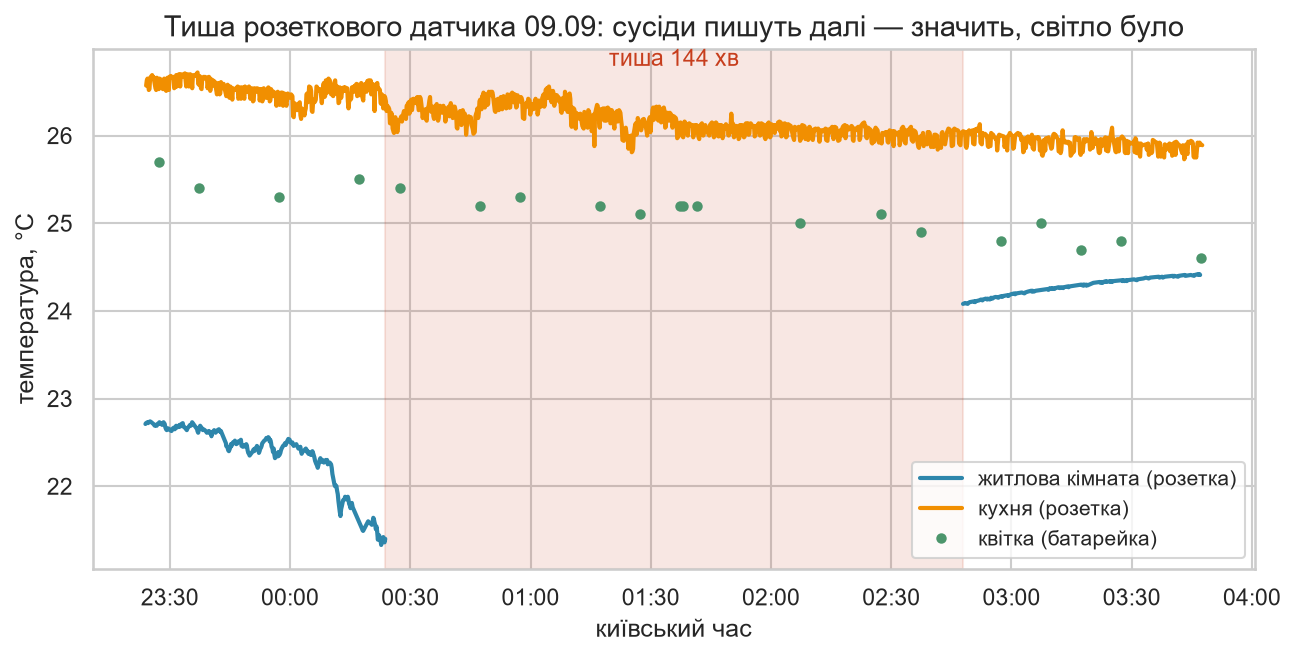

In [4]:
p = outages.plot_short_example(detailed, IMAGES / "m2_short_outage_example.png")
display(Image(filename=str(p)))

Ось як це виглядає: датчик житлової кімнати мовчить 144 хвилини (рожева зона),
а кухня (розетка) і квітка (батарейка) пишуть без пауз.
**Це не блекаут, а збій одного датчика** — і саме так наш метод відрізняє одне від одного.
Під час справжнього відключення обидві розеткові лінії обірвалися б разом,
а зелені крапки квітки лишилися б.

## Сигнал B — довгі відключення (6 місяців)

Тут детальних даних уже немає — лише погодинні. Годину вважаємо «без світла»,
коли **всі доступні розеткові датчики мовчать одночасно**.

«Доступні» — це важливо:

* датчик ще не встановлений → він не свідок (кладова з 04.04, сервер з 01.04, NAS з 20.04);
* датчик у серії `stuck` з M1 → він теж не свідок: **застряглий датчик ≠ блекаут**;
* кухня взагалі не бере участі — у неї власні 30-денні дірки (покриття 68 %),
  вона б давала хибні спрацювання.

In [5]:
m = outages.mains_alive_matrix(hourly)
witnesses = m.notna().sum(axis=1)
alive = m.eq(True).sum(axis=1)
pd.DataFrame({
    "годин у періоді": [len(m)],
    "годин з ≥1 свідком": [int((witnesses > 0).sum())],
    "годин, де всі свідки мовчать": [int(((witnesses > 0) & (alive == 0)).sum())],
})

,годин у періоді,годин з ≥1 свідком,"годин, де всі свідки мовчать"
0,4402,4377,35


In [6]:
long_ev = outages.find_outages_hourly(hourly)
long_ev.assign(start_kyiv=long_ev.start.dt.tz_convert("Europe/Kyiv"))[
    ["start", "start_kyiv", "end", "hours", "n_witnesses", "witnesses"]]

,start,start_kyiv,end,hours,n_witnesses,witnesses
0,2026-03-18 01:00:00+00:00,2026-03-18 03:00:00+02:00,2026-03-18 07:00:00+00:00,6,1,bedroom_temp
1,2026-06-13 08:00:00+00:00,2026-06-13 11:00:00+03:00,2026-06-13 16:00:00+00:00,8,4,"bedroom_temp, printernya_temp, server_cpu_load, nas_sda_temp"
2,2026-07-11 09:00:00+00:00,2026-07-11 12:00:00+03:00,2026-07-11 14:00:00+00:00,5,4,"bedroom_temp, printernya_temp, server_cpu_load, nas_sda_temp"
3,2026-07-12 08:00:00+00:00,2026-07-12 11:00:00+03:00,2026-07-12 15:00:00+00:00,7,4,"bedroom_temp, printernya_temp, server_cpu_load, nas_sda_temp"
4,2026-07-25 08:00:00+00:00,2026-07-25 11:00:00+03:00,2026-07-25 17:00:00+00:00,9,4,"bedroom_temp, printernya_temp, server_cpu_load, nas_sda_temp"


## Таблиця подій

Зводимо обидва сигнали в одну таблицю `results/m2_outages.csv` — це контракт
для M4, M8 і M9. Дублікати (подія, видима обома способами) прибираємо
на користь детальних даних, бо вони точніші. Тут дублікатів немає:
у 10-денному вікні відключень не було взагалі.

In [7]:
events = outages.build_event_table(confirmed, long_ev, hourly)
events[["event_id", "source", "start_kyiv", "end_kyiv", "hours", "weekday_kyiv",
        "start_hour_kyiv", "soil_alive"]]

,event_id,source,start_kyiv,end_kyiv,hours,weekday_kyiv,start_hour_kyiv,soil_alive
0,OUT-001,hourly,2026-03-18 03:00:00+02:00,2026-03-18 09:00:00+02:00,6.0,Wed,3,<NA>
1,OUT-002,hourly,2026-06-13 11:00:00+03:00,2026-06-13 19:00:00+03:00,8.0,Sat,11,<NA>
2,OUT-003,hourly,2026-07-11 12:00:00+03:00,2026-07-11 17:00:00+03:00,5.0,Sat,12,<NA>
3,OUT-004,hourly,2026-07-12 11:00:00+03:00,2026-07-12 18:00:00+03:00,7.0,Sun,11,<NA>
4,OUT-005,hourly,2026-07-25 11:00:00+03:00,2026-07-25 20:00:00+03:00,9.0,Sat,11,<NA>


In [8]:
for r in events.itertuples():
    print(f"{r.event_id}  {r.start_kyiv:%d.%m %H:%M} → {r.end_kyiv:%H:%M}  {r.hours:.0f} год")
    print(f"           {r.notes}\n")

OUT-001  18.03 03:00 → 09:00  6 год
           мовчать усі доступні розеткові датчики (1): bedroom_temp; НИЗЬКА ВПЕВНЕНІСТЬ: у той час працював лише один розетковий датчик

OUT-002  13.06 11:00 → 19:00  8 год
           мовчать усі доступні розеткові датчики (4): bedroom_temp, printernya_temp, server_cpu_load, nas_sda_temp

OUT-003  11.07 12:00 → 17:00  5 год
           мовчать усі доступні розеткові датчики (4): bedroom_temp, printernya_temp, server_cpu_load, nas_sda_temp; квітка теж мовчала → сервер був вимкнений

OUT-004  12.07 11:00 → 18:00  7 год
           мовчать усі доступні розеткові датчики (4): bedroom_temp, printernya_temp, server_cpu_load, nas_sda_temp; квітка теж мовчала → сервер був вимкнений

OUT-005  25.07 11:00 → 20:00  9 год
           мовчать усі доступні розеткові датчики (4): bedroom_temp, printernya_temp, server_cpu_load, nas_sda_temp; квітка теж мовчала → сервер був вимкнений



### Чому цифри не збіглися з чернеткою

Перший, «на око», прохід по даних давав **7 подій / 53 години, найдовша 15 годин 10.06**.
Суворе правило дає **5 подій / 35 годин, найдовша 9 годин 25.07**. Дві події відпали —
і обидві з цікавої причини.

In [9]:
from src.cleaning import stuck_runs
sr = stuck_runs(hourly)
sr[sr.hours > 20][["entity_id", "start", "end", "value", "hours"]]

,entity_id,start,end,value,hours
0,sensor.test_product_humidity,2026-03-22 14:00:00+00:00,2026-03-23 14:00:00+00:00,43.30,25
1,sensor.test_product_humidity,2026-08-18 10:00:00+00:00,2026-08-24 09:00:00+00:00,32.00,144
2,sensor.test_product_humidity_2,2026-07-27 22:00:00+00:00,2026-07-28 20:00:00+00:00,40.18,23
3,sensor.test_product_temperature,2026-03-22 14:00:00+00:00,2026-03-23 14:00:00+00:00,23.00,25
4,sensor.test_product_temperature,2026-08-18 10:00:00+00:00,2026-08-24 09:00:00+00:00,26.36,144
5,sensor.test_product_temperature_2,2026-07-27 22:00:00+00:00,2026-07-28 20:00:00+00:00,27.93,23


**Хибне спрацювання №1 — застряглий датчик (22–23.03, 25 годин).**
Датчик житлової кімнати 25 годин поспіль віддавав рівно `23.00 °C` і `43.30 %`.
Запис у базі був — а вимірювання не було. Для «дірки в даних» це виглядає як
працюючий датчик, для «значення не змінюється» — як блекаут.
Ми позначили такі години прапорцем `stuck` ще в M1 і тут не рахуємо їх
ні за наявні, ні за відсутні: датчик просто не свідок.

У тій же таблиці видно ще одне застрягання — **144 години у серпні** (18–24.08).
Це рекорд усього проєкту, і це теж не блекаут: датчик замерз, а не квартира.

In [10]:
w = pd.read_csv(ROOT / "data/clean/hours_wide.csv")
w["ts"] = pd.to_datetime(w.ts, utc=True, format="mixed")
day = w[(w.ts >= "2026-06-09 20:00+00:00") & (w.ts <= "2026-06-10 13:00+00:00")]
cols = ["bedroom_temp", "kitchen_temp", "printernya_temp", "server_cpu_load", "nas_sda_temp"]
(day.set_index(day.ts.dt.strftime("%d.%m %H:00"))[cols]
    .notna().astype(int).T.rename(index={"bedroom_temp": "кімната", "kitchen_temp": "кухня",
                                         "printernya_temp": "кладова",
                                         "server_cpu_load": "сервер", "nas_sda_temp": "NAS"}))

ts,09.06 20:00,09.06 21:00,09.06 22:00,09.06 23:00,10.06 00:00,10.06 01:00,10.06 02:00,10.06 03:00,10.06 04:00,10.06 05:00,10.06 06:00,10.06 07:00,10.06 08:00,10.06 09:00,10.06 10:00,10.06 11:00,10.06 12:00,10.06 13:00
кімната,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
кухня,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
кладова,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
сервер,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
NAS,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


**Хибне спрацювання №2 — впала Zigbee-мережа (09–10.06, ~15 годин).**
Усі три кімнатні датчики замовкли разом — виглядає як ідеальний блекаут.
Але сервер і NAS у ті самі години писали без жодної паузи (одиниці в таблиці вище).
Світло було; впав радіоміст до датчиків.

Саме тому в правилі стоїть «мовчать **усі** розеткові датчики», а не «мовчать кімнати».
Техніка тут — незалежний свідок, і вона цю подію знімає.

## Метрики

In [11]:
metrics = outages.outage_metrics(events, hourly, candidates, sil)
key = ["n_events_total", "n_short", "n_long", "median_hours", "max_hours",
       "max_event_date", "total_hours", "uptime_pct", "total_calendar_hours"]
pd.DataFrame({"метрика": key, "значення": [metrics[k] for k in key]})

,метрика,значення
0,n_events_total,5
1,n_short,0
2,n_long,5
3,median_hours,7.0
4,max_hours,9.0
5,max_event_date,2026-07-25
6,total_hours,35.0
7,uptime_pct,99.205
8,total_calendar_hours,4402


In [12]:
months = [k for k in metrics if k.startswith("hours_2026")]
wd = [k for k in metrics if k.startswith("events_weekday_")]
pd.DataFrame({
    "місяць": [k.replace("hours_2026_", "") for k in months],
    "годин без світла": [metrics[k] for k in months],
}).T

,0,1,2,3,4,5,6
місяць,03,04,05,06,07,08,09
годин без світла,6,0,0,8,21,0,0


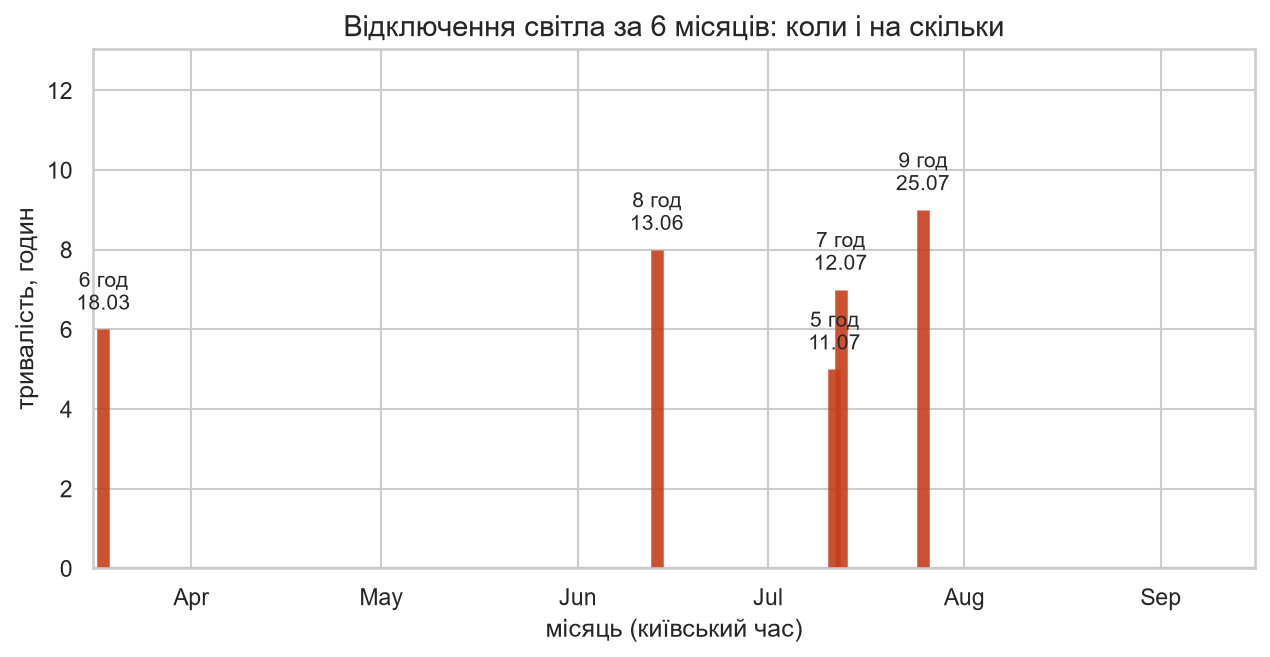

In [13]:
p = outages.plot_timeline(events, hourly, IMAGES / "m2_timeline.png")
display(Image(filename=str(p)))

Відключення не розмазані по пів року, а зібрані в три тижні: 13.06, 11–12.07 і 25.07.
Квітень, травень, серпень і вересень — чисті.

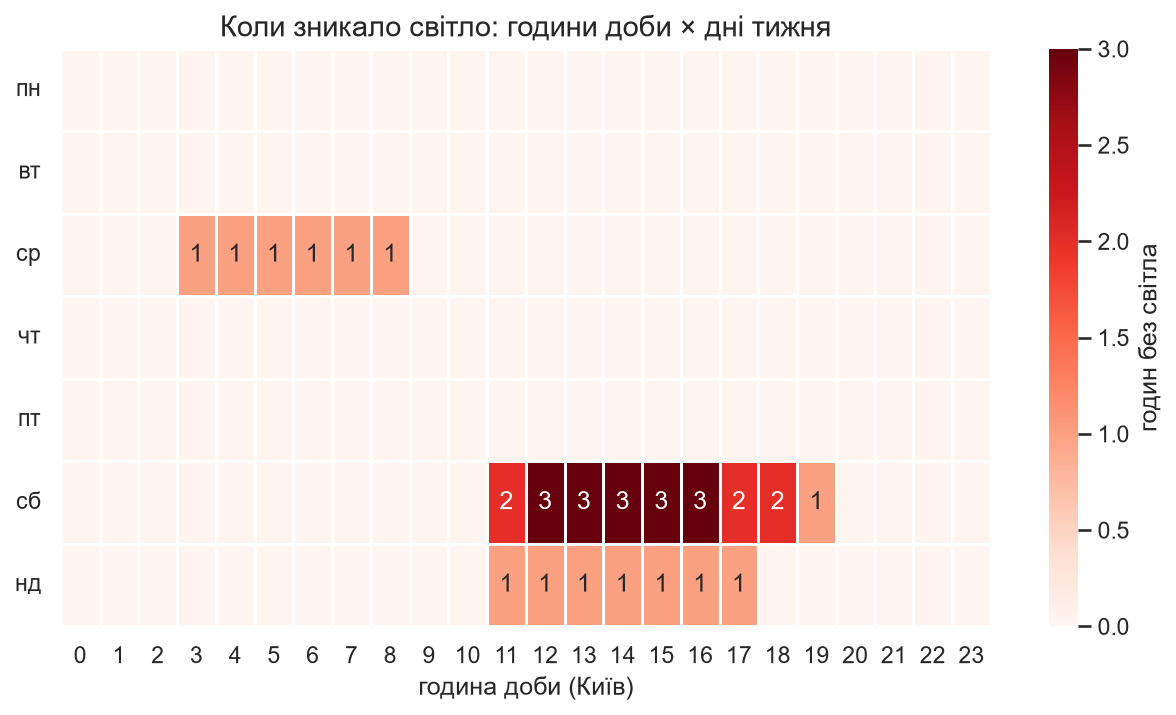

In [14]:
p = outages.plot_heatmap(events, IMAGES / "m2_heatmap_hour_weekday.png")
display(Image(filename=str(p)))

Найцікавіше в усьому модулі: **4 з 5 подій почалися об 11:00–12:00 за Києвом,
три з них — у суботу**. Це не схоже на аварію: це схоже на планові роботи.
Ніч і вечір — повністю чисті.

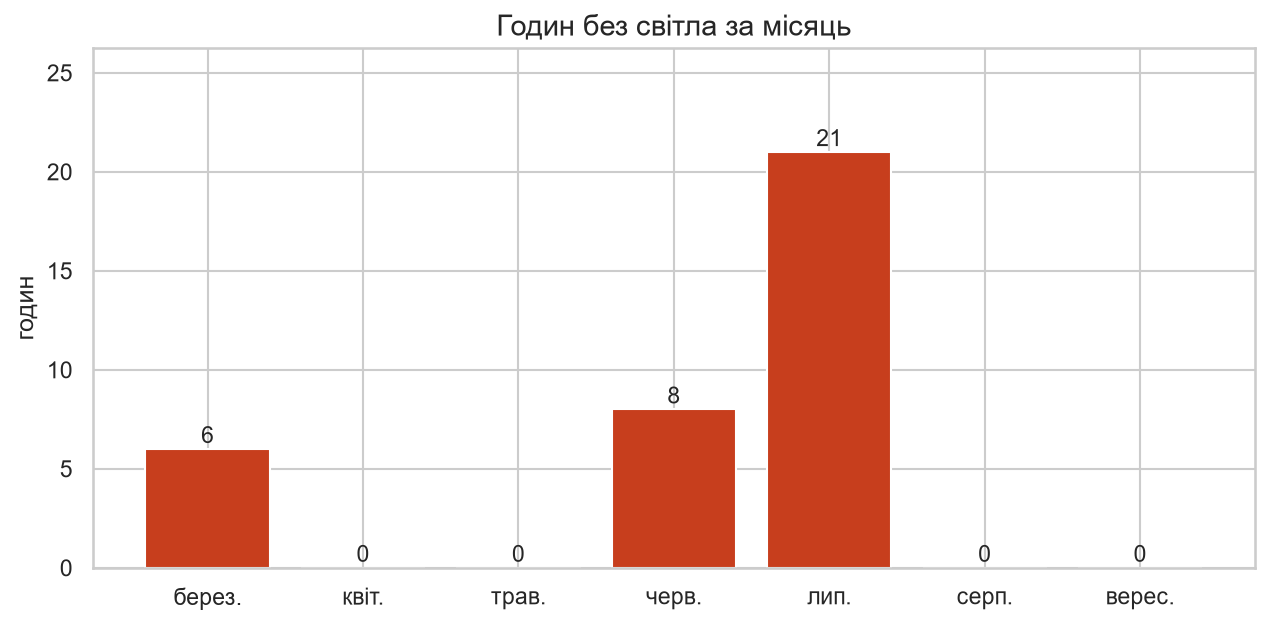

In [15]:
p = outages.plot_monthly(events, hourly, IMAGES / "m2_monthly_hours.png")
display(Image(filename=str(p)))

Липень забрав 21 годину з 35 — більше, ніж решта місяців разом.

In [16]:
events.to_csv(RESULTS / "m2_outages.csv", index=False)
(RESULTS / "m2_outages.json").write_text(json.dumps(metrics, ensure_ascii=False, indent=2),
                                         encoding="utf-8")
print("results/m2_outages.csv  —", len(events), "подій")
print("results/m2_outages.json —", len(metrics), "метрик")

results/m2_outages.csv  — 5 подій
results/m2_outages.json — 41 метрик


## Обмеження

Чесний список того, чого ці цифри **не** доводять.

| Обмеження | Що це означає |
|---|---|
| **ДБЖ ховає найкоротші відключення** | сервер живе на батареї й пише далі, тому відключення на 10 секунд ми не побачимо взагалі |
| **Поріг 3 хвилини** | усе коротше свідомо викинуто як шум — це рішення, а не вимір |
| **Погодинна роздільність для старих подій** | глибше за 10 днів ми бачимо лише години: відключення на 20 хвилин або зникає, або виглядає як ціла година. Тривалості округлені до годин |
| **Застряглий датчик ≠ блекаут** | і навпаки: години `stuck` ми виключаємо, тож реальне відключення всередині такої серії ми б не побачили |
| **Контроль квіткою слабкий** | вона пише раз на ~20 хвилин, має власні дірки (11–15.09) і встановлена лише з 14.06 — для коротких подій вона нічого не доводить |
| **Одна подія на одному свідку** | 18.03 працював лише один розетковий датчик, підтвердити нічим (позначено в `notes`) |
| **Кухня не свідок** | покриття 68 % із власними 30-денними дірками — вона б додала хибних подій |
| **Це не дані обленерго** | ми міряємо не «світло в місті», а «живлення в цій квартирі» |

## Висновки

* **5 відключень за пів року, 35 годин без світла** — це **uptime 99,2 %**
  (35 годин із 4 402).
* **Найдовше — 9 годин, 25.07.2026** (субота, з 11:00 до 20:00 за Києвом).
  Медіана події — **7 годин**: коротких відключень у цих даних немає взагалі.
* **Липень — найважчий місяць: 21 година** з 35. Квітень, травень, серпень
  і вересень — без жодного відключення.
* **4 з 5 подій починалися об 11:00–12:00, три — у суботу.** Схоже не на аварії,
  а на планові роботи.
* **Дві «події» виявилися не блекаутами**: застряглий на 25 годин датчик (22–23.03)
  і падіння Zigbee-мережі на 15 годин (09–10.06), під час якого сервер і NAS
  спокійно писали далі. Перевірка іншими датчиками прибрала обидві.

## Як сказати на співбесіді за 30 секунд

> У квартирі немає датчика напруги, тому відключення я шукала не по значенню, а
> **по тиші в даних**: усі датчики живляться від розетки, крім одного на батарейці,
> а сервер стоїть на ДБЖ — звідси два різні сигнали. Правило просте: пауза між
> записами ≥ 3 хвилин — це відключення; в SQL це один `LAG(ts) OVER (ORDER BY ts)`.
> Вийшло 5 подій і 35 годин без світла за пів року — uptime 99,2 %, найдовша подія
> 9 годин. Але цікаве не число, а те, що правило спершу давало 7 подій: одна
> виявилася застряглим датчиком, який 25 годин повторював те саме значення, друга —
> падінням Zigbee-мережі, під час якого сервер і NAS писали далі. Дві хибні події з
> семи прибрала саме перевірка незалежними датчиками — і ця таблиця подій далі
> працює як вхід для розрахунку, наскільки швидко квартира втрачає тепло.